**Load Libraries**

In [1]:
import pandas as pd
import numpy as np
import sklearn
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve

Load Dataset

In [2]:
df = pd.read_csv(r"diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


Select Features (No-Hospital-Needed Only)

For a self-screening tool, the user can't walk in with lab results. So we drop
`HbA1c_level` and `blood_glucose_level` — both require a blood draw at a clinic.
Everything else here is something a person can self-report at home.

In [4]:
feature_cols = ["gender", "age", "hypertension", "heart_disease", "smoking_history", "bmi"]

X = df[feature_cols]
y = df["diabetes"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

print("Categorical columns:", list(cat_cols))
print("Numeric columns:", list(num_cols))

Categorical columns: ['gender', 'smoking_history']
Numeric columns: ['age', 'hypertension', 'heart_disease', 'bmi']


C:\Users\Micheal Adeniyi\AppData\Local\Temp\ipykernel_31008\3365036701.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


Split Dataset For Training

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Train Logistic Regression Model

In [6]:
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

log_reg = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg.fit(X_train, y_train)

log_reg_pred = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression AUC:", roc_auc_score(y_test, log_reg_pred))

Logistic Regression AUC: 0.8381493731918996


Train HistGradientBoosting Model

`HistGradientBoostingClassifier` is scikit-learn's built-in gradient boosting
model — no extra library needed (no xgboost/lightgbm), and it usually
outperforms both Logistic Regression and Random Forest on tabular data like
this, while staying small when saved.

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_gb = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=150,
        max_depth=6,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42
    ))
])

hist_gb.fit(X_train, y_train)

hist_gb_pred = hist_gb.predict_proba(X_test)[:, 1]

print("HistGradientBoosting AUC:", roc_auc_score(y_test, hist_gb_pred))

HistGradientBoosting AUC: 0.8369323368691739


Compare Models

Whichever model scores higher on AUC above is the one we carry forward and
calibrate. Update `best_model` below if Logistic Regression wins on your run.

In [8]:
auc_log_reg = roc_auc_score(y_test, log_reg_pred)
auc_hist_gb = roc_auc_score(y_test, hist_gb_pred)

print(f"Logistic Regression AUC: {auc_log_reg:.4f}")
print(f"HistGradientBoosting AUC: {auc_hist_gb:.4f}")

best_model = hist_gb if auc_hist_gb >= auc_log_reg else log_reg
best_model_name = "hist_gb" if auc_hist_gb >= auc_log_reg else "log_reg"

print("Best model:", best_model_name)

Logistic Regression AUC: 0.8381
HistGradientBoosting AUC: 0.8369
Best model: log_reg


Calibrate the Best Model

Calibration improves how trustworthy the predicted probabilities are —
important since we're about to pick a threshold based on those probabilities.

In [9]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(best_model, cv=5)
calibrated_model.fit(X_train, y_train)

calibrated_pred = calibrated_model.predict_proba(X_test)[:, 1]

print("Calibrated AUC:", roc_auc_score(y_test, calibrated_pred))

Calibrated AUC: 0.8381450658952105


Choose Threshold for Recall >= 0.90

Same idea as a diagnostic screening test: we'd rather flag some healthy people
for a follow-up test than miss someone who actually has diabetes. So we pick
the threshold that keeps recall at 90% or higher.

In [10]:
precision, recall, thresholds = precision_recall_curve(y_test, calibrated_pred)

pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

candidate_thresholds = pr_df[pr_df["recall"] >= 0.9]
best_threshold = candidate_thresholds["threshold"].max()

print(f"Selected threshold for recall >= 0.9: {best_threshold:.3f}")

y_pred_binary = (calibrated_pred >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_binary, target_names=["No Diabetes", "Diabetes Risk"]))

Selected threshold for recall >= 0.9: 0.055
               precision    recall  f1-score   support

  No Diabetes       0.98      0.60      0.75     18300
Diabetes Risk       0.17      0.90      0.29      1700

     accuracy                           0.63     20000
    macro avg       0.58      0.75      0.52     20000
 weighted avg       0.92      0.63      0.71     20000



Precision-Recall vs Threshold Plot

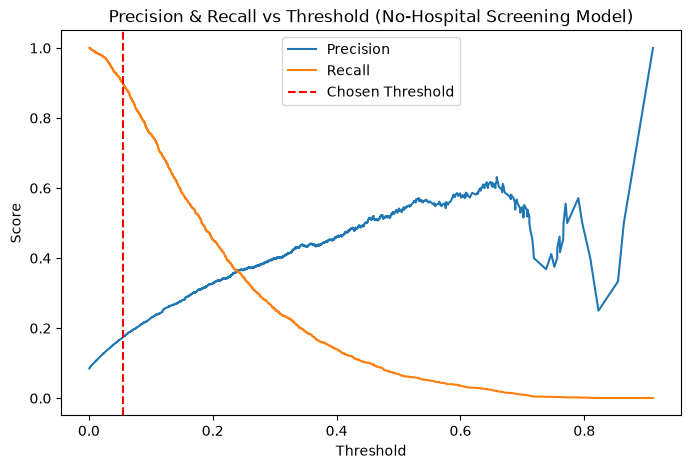

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(best_threshold, color="red", linestyle="--", label="Chosen Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold (No-Hospital Screening Model)")
plt.legend()
plt.show()

Save Screening Model

In [12]:
import pickle

# Save the calibrated screening model
with open("diabetes_screening_model.pkl", "wb") as f:
    pickle.dump(calibrated_model, f)

# Save the threshold
with open("screening_threshold.pkl", "wb") as f:
    pickle.dump(best_threshold, f)

print("Screening model and threshold saved successfully!")

Screening model and threshold saved successfully!


In [13]:
import os

size_mb = os.path.getsize("diabetes_screening_model.pkl") / (1024 * 1024)
print(f"Model file size: {size_mb:.2f} MB")

Model file size: 0.01 MB
